# 09 · Baseline Models — Sprint 3
**Proyecto:** Detección de Sitios Web Fraudulentos (Phishing)  
**Sprint 3 — PB-10:** Entrenamiento de modelos baseline de clasificación  

---

## Objetivo

Entrenar al menos 5 modelos baseline con **parámetros por defecto**, encapsulados
en un `Pipeline(preproc, clf)` completo, de modo que `cross_validate` aplique el
preprocesamiento correctamente en cada fold y se evite *data leakage*.

## Modelos entrenados

| # | Modelo | Justificación de inclusión |
|---|--------|----------------------------|
| 1 | Logistic Regression | Baseline lineal, interpretable, rápido |
| 2 | Decision Tree | Baseline no-lineal, interpretable, propenso a overfitting |
| 3 | Random Forest | Ensemble robusto, suele ser competitivo en datos tabulares |
| 4 | Gradient Boosting | Boosting secuencial, muy competitivo en tabular |
| 5 | SVM | Fuerte en alta dimensionalidad, sensible a escala |
| 6 | KNN | Simple, no paramétrico, referencia de vecindad |
| 7 | Naive Bayes | Probabilístico, muy rápido, asume independencia |

> ⚠️ **Clave Sprint 3:** Solo parámetros por defecto. El tuning se hace en Sprint 4.

## Insumos del Sprint 2

- `data/processed/train_preprocessed.csv` — dataset balanceado con SMOTE (4 679 filas, 37 features + target)
- `models/preprocessor.pkl` — pipeline de preprocesamiento (imputer + scaler) entrenado en Sprint 2


## 1. Imports y configuración

In [3]:
import sys
import os
import warnings
warnings.filterwarnings('ignore')

# Agregar raíz del proyecto al path
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

# Módulo del Sprint 3
from src.models import (
    get_baseline_models,
    build_full_pipeline,
    train_baseline,
    evaluate_model,
    log_experiment,
)

RANDOM_STATE = 42
sns.set_theme(style='whitegrid', palette='muted')
print('✓ Librerías cargadas.')

✓ Librerías cargadas.


## 2. Cargar datos y pipeline del Sprint 2

Se carga el dataset ya balanceado con SMOTE (`train_preprocessed.csv`) y el
pipeline de preprocesamiento (`preprocessor.pkl`) generado en el notebook `08_pipeline.ipynb`.

> **Nota importante:** Aunque `train_preprocessed.csv` ya está escalado, volvemos
> a usar los datos **sin escalar** desde `train.csv` para pasar datos crudos al
> Pipeline completo, que internamente aplica el escalado. Esto garantiza que
> `cross_validate` no genere *data leakage*.


In [4]:
# Cargar datos crudos (ya con SMOTE aplicado, sin escalar)
train_df = pd.read_csv('../data/processed/train.csv')

TARGET_COL = 'Result'
X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

# Cargar pipeline de preprocesamiento del Sprint 2
preprocessor = joblib.load('../models/preprocessor.pkl')

print(f'X_train shape: {X_train.shape}')
print(f'y_train distribución: {dict(y_train.value_counts().sort_index())}')
print(f'Features: {X_train.columns.tolist()}')

X_train shape: (4830, 37)
y_train distribución: {-1: np.int64(2415), 1: np.int64(2415)}
Features: ['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Prefix_Suffix', 'having_Sub_Domain', 'SSLfinal_State', 'Domain_registeration_length', 'Favicon', 'port', 'HTTPS_token', 'Request_URL', 'URL_of_Anchor', 'Links_in_tags', 'SFH', 'Submitting_to_email', 'Abnormal_URL', 'Redirect', 'on_mouseover', 'RightClick', 'popUpWidnow', 'Iframe', 'age_of_domain', 'DNSRecord', 'web_traffic', 'Page_Rank', 'Google_Index', 'Links_pointing_to_page', 'Statistical_report', 'url_risk_score', 'security_score', 'total_suspicious_count', 'total_legitimate_count', 'net_signal_ratio', 'ssl_traffic_interaction', 'content_risk_score']


## 3. Definición de modelos baseline

Todos los modelos se instancian con `random_state=42` donde aplica,
para garantizar reproducibilidad. Los parámetros son los defaults de sklearn.

In [5]:
classifiers = get_baseline_models()

print('Modelos baseline definidos:')
for i, (name, clf) in enumerate(classifiers.items(), 1):
    print(f'  {i}. {name}: {clf.__class__.__name__}')

Modelos baseline definidos:
  1. Logistic Regression: LogisticRegression
  2. Decision Tree: DecisionTreeClassifier
  3. Random Forest: RandomForestClassifier
  4. Gradient Boosting: GradientBoostingClassifier
  5. SVM: SVC
  6. KNN: KNeighborsClassifier
  7. Naive Bayes: GaussianNB


## 4. Construcción del Pipeline completo

Cada baseline se envuelve en un `Pipeline(preproc, clf)`. Esto garantiza que:

1. El `preprocessor` se ajusta **solo en el fold de entrenamiento** (no hay *leakage*).
2. Se aplica `transform` al fold de validación con el preprocesamiento aprendido en train.
3. El pipeline completo puede ser persistido con `joblib` como un único objeto.

**Mal (❌):** preprocesar por separado y pasar los datos ya escalados a `cross_validate`.  
**Bien (✅):** pasar datos crudos al Pipeline completo y dejar que `cross_validate` gestione todo.


In [6]:
# Construir pipelines completos
pipelines = {}
for name, clf in classifiers.items():
    pipe = build_full_pipeline(preprocessor, clf)
    pipelines[name] = pipe
    print(f'✓ Pipeline construido: {name}')

# Verificar estructura de uno de los pipelines
print('\nEstructura del pipeline (Random Forest):')
print(pipelines['Random Forest'])

✓ Pipeline construido: Logistic Regression
✓ Pipeline construido: Decision Tree
✓ Pipeline construido: Random Forest
✓ Pipeline construido: Gradient Boosting
✓ Pipeline construido: SVM
✓ Pipeline construido: KNN
✓ Pipeline construido: Naive Bayes

Estructura del pipeline (Random Forest):
Pipeline(steps=[('preproc',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['having_IP_Address',
                                                   'URL_Length',
                                                   'Shortining_Service',
                                                   'having_At_Symbol',


## 5. Entrenamiento de modelos baseline

Se entrena cada pipeline sobre el conjunto completo de entrenamiento y se
persiste en `models/baseline_<nombre>.pkl`. Los archivos generados son:

- `models/baseline_logistic_regression.pkl`
- `models/baseline_decision_tree.pkl`
- `models/baseline_random_forest.pkl`
- `models/baseline_gradient_boosting.pkl`
- `models/baseline_svm.pkl`
- `models/baseline_knn.pkl`
- `models/baseline_naive_bayes.pkl`


In [7]:
os.makedirs('../models', exist_ok=True)

trained_pipelines = {}
for name, pipe in pipelines.items():
    short = name.lower().replace(' ', '_')
    trained = train_baseline(pipe, X_train, y_train, short, model_dir='../models')
    trained_pipelines[name] = trained

print('\n✅ Todos los modelos entrenados y persistidos.')

[train_baseline] 'logistic_regression' entrenado y guardado en '../models\baseline_logistic_regression.pkl'.
[train_baseline] 'decision_tree' entrenado y guardado en '../models\baseline_decision_tree.pkl'.
[train_baseline] 'random_forest' entrenado y guardado en '../models\baseline_random_forest.pkl'.
[train_baseline] 'gradient_boosting' entrenado y guardado en '../models\baseline_gradient_boosting.pkl'.
[train_baseline] 'svm' entrenado y guardado en '../models\baseline_svm.pkl'.
[train_baseline] 'knn' entrenado y guardado en '../models\baseline_knn.pkl'.
[train_baseline] 'naive_bayes' entrenado y guardado en '../models\baseline_naive_bayes.pkl'.

✅ Todos los modelos entrenados y persistidos.


## 6. Evaluación con cross-validation estratificada

Se usa `StratifiedKFold(n_splits=5)` para mantener la proporción de clases
en cada fold. Se evalúan 5 métricas:

- **Accuracy** — proporción de aciertos totales (referencia, puede ser engañosa si hay desbalance).
- **F1-Score** — media armónica de precision y recall. **Métrica principal** por el desbalance potencial.
- **AUC-ROC** — capacidad de discriminación general del modelo.
- **Recall** — detecta qué porcentaje de sitios phishing reales son capturados (falso negativo = alto costo).
- **Precision** — de los clasificados como phishing, cuántos lo son realmente.


In [8]:
cv_results = {}

for name, pipe in trained_pipelines.items():
    print(f'Evaluando: {name}...')
    results = evaluate_model(pipe, X_train, y_train, cv_folds=5)
    cv_results[name] = results

    f1_mean = results['test_f1'].mean()
    f1_std  = results['test_f1'].std()
    auc_mean = results['test_roc_auc'].mean()
    print(f'  F1 (CV):     {f1_mean:.4f} ± {f1_std:.4f}')
    print(f'  AUC-ROC (CV): {auc_mean:.4f}')

print('\n✅ Cross-validation completada para todos los modelos.')

Evaluando: Logistic Regression...
  F1 (CV):     0.9350 ± 0.0058
  AUC-ROC (CV): 0.9839
Evaluando: Decision Tree...
  F1 (CV):     0.9153 ± 0.0039
  AUC-ROC (CV): 0.9194
Evaluando: Random Forest...
  F1 (CV):     0.9419 ± 0.0076
  AUC-ROC (CV): 0.9861
Evaluando: Gradient Boosting...
  F1 (CV):     0.9417 ± 0.0042
  AUC-ROC (CV): 0.9881
Evaluando: SVM...
  F1 (CV):     0.9422 ± 0.0052
  AUC-ROC (CV): 0.9843
Evaluando: KNN...
  F1 (CV):     0.9298 ± 0.0110
  AUC-ROC (CV): 0.9777
Evaluando: Naive Bayes...
  F1 (CV):     0.5740 ± 0.0181
  AUC-ROC (CV): 0.9556

✅ Cross-validation completada para todos los modelos.


## 7. Tabla comparativa de resultados

In [9]:
records = []
for name, res in cv_results.items():
    train_f1 = res['train_f1'].mean()
    test_f1  = res['test_f1'].mean()
    gap = train_f1 - test_f1
    records.append({
        'Modelo':       name,
        'Accuracy':     round(res['test_accuracy'].mean(), 4),
        'F1':           round(test_f1, 4),
        'F1_std':       round(res['test_f1'].std(), 4),
        'AUC-ROC':      round(res['test_roc_auc'].mean(), 4),
        'Recall':       round(res['test_recall'].mean(), 4),
        'Precision':    round(res['test_precision'].mean(), 4),
        'Train_F1':     round(train_f1, 4),
        'Overfit_Gap':  round(gap, 4),
        'Overfitting?': '⚠️ Sí' if gap > 0.10 else 'OK',
    })

df_results = pd.DataFrame(records).sort_values('F1', ascending=False).reset_index(drop=True)
df_results.index += 1

# Guardar CSV de resultados
df_results.to_csv('../models/baseline_comparison.csv', index=False)

# Mostrar tabla
df_results.style \
    .highlight_max(subset=['F1', 'AUC-ROC', 'Recall', 'Precision', 'Accuracy'], color='#c8e6c9') \
    .highlight_min(subset=['F1', 'AUC-ROC', 'Recall', 'Precision', 'Accuracy'], color='#ffcdd2') \
    .format({'F1': '{:.4f}', 'AUC-ROC': '{:.4f}', 'Recall': '{:.4f}',
             'Precision': '{:.4f}', 'Accuracy': '{:.4f}'})

,Modelo,Accuracy,F1,F1_std,AUC-ROC,Recall,Precision,Train_F1,Overfit_Gap,Overfitting?
1,SVM,0.9414,0.9422,0.005200,0.9843,0.9553,0.9295,0.954900,0.012700,OK
2,Random Forest,0.9414,0.9419,0.007600,0.9861,0.9507,0.9334,0.993000,0.051000,OK
3,Gradient Boosting,0.9412,0.9417,0.004200,0.9881,0.9503,0.9334,0.952200,0.010500,OK
4,Logistic Regression,0.9344,0.9350,0.005800,0.9839,0.9449,0.9255,0.937000,0.002000,OK
5,KNN,0.9302,0.9298,0.011000,0.9777,0.9255,0.9344,0.956400,0.026500,OK
6,Decision Tree,0.9155,0.9153,0.003900,0.9194,0.9135,0.9173,0.992900,0.077600,OK
7,Naive Bayes,0.7012,0.5740,0.018100,0.9556,0.4029,0.9990,0.573200,-0.000700,OK


## 8. Visualización: F1-Score por modelo

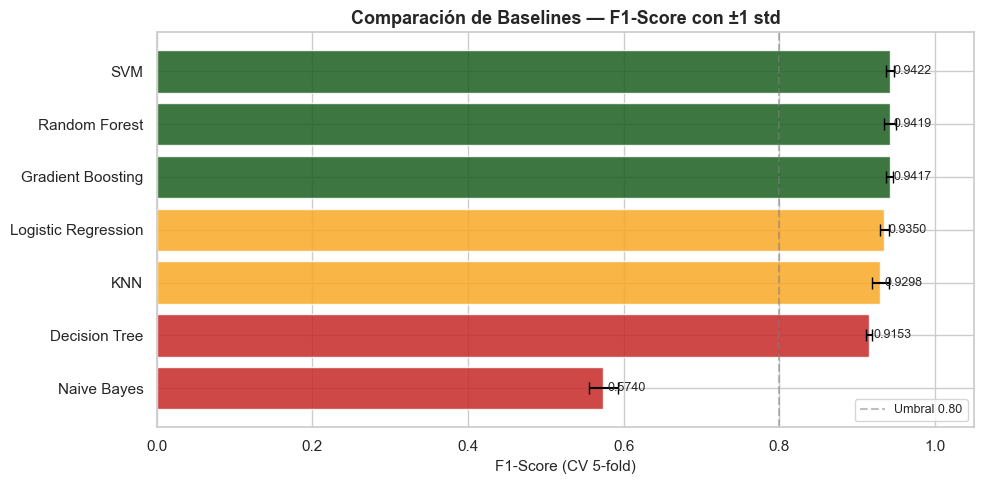

In [10]:
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['#1b5e20' if i < 3 else ('#f9a825' if i < 5 else '#c62828')
          for i in range(len(df_results))]

bars = ax.barh(
    df_results['Modelo'],
    df_results['F1'],
    xerr=df_results['F1_std'],
    color=colors,
    alpha=0.85,
    capsize=4,
    error_kw={'elinewidth': 1.5, 'ecolor': 'black'},
)

for bar, val in zip(bars, df_results['F1']):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

ax.set_xlabel('F1-Score (CV 5-fold)', fontsize=11)
ax.set_title('Comparación de Baselines — F1-Score con ±1 std', fontsize=13, fontweight='bold')
ax.set_xlim(0, 1.05)
ax.axvline(0.80, color='gray', linestyle='--', alpha=0.5, label='Umbral 0.80')
ax.legend(fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../models/baseline_f1_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Verificación de carga de modelos

Se verifica que cada modelo persistido puede cargarse desde disco y generar
predicciones correctamente sobre observaciones nuevas (datos crudos).

In [11]:
# Cargar test set para verificación
test_df = pd.read_csv('../data/processed/test.csv')
X_test_raw = test_df.drop(columns=[TARGET_COL])
sample = X_test_raw.iloc[:5]

print('Verificación de carga y predicción (5 observaciones del test set):')
print('-' * 60)

for name, _ in classifiers.items():
    short = name.lower().replace(' ', '_')
    pipe_loaded = joblib.load(f'../models/baseline_{short}.pkl')
    preds = pipe_loaded.predict(sample)
    print(f'  {name:25s} → {preds.tolist()}')

print('\n✅ Todos los modelos verificados: cargan y predicen correctamente.')

Verificación de carga y predicción (5 observaciones del test set):
------------------------------------------------------------
  Logistic Regression       → [-1, -1, -1, -1, 1]
  Decision Tree             → [-1, -1, -1, -1, 1]
  Random Forest             → [-1, -1, -1, -1, 1]
  Gradient Boosting         → [-1, -1, -1, -1, 1]
  SVM                       → [-1, -1, -1, -1, 1]
  KNN                       → [-1, -1, -1, -1, 1]
  Naive Bayes               → [-1, -1, -1, -1, -1]

✅ Todos los modelos verificados: cargan y predicen correctamente.


## 10. Registro de experimentos

In [12]:
for name, res in cv_results.items():
    clf = classifiers[name]
    metrics = {
        'f1_cv_mean':        round(res['test_f1'].mean(), 4),
        'auc_cv_mean':       round(res['test_roc_auc'].mean(), 4),
        'recall_cv_mean':    round(res['test_recall'].mean(), 4),
        'precision_cv_mean': round(res['test_precision'].mean(), 4),
        'accuracy_cv_mean':  round(res['test_accuracy'].mean(), 4),
        'train_f1_mean':     round(res['train_f1'].mean(), 4),
    }
    gap = metrics['train_f1_mean'] - metrics['f1_cv_mean']
    notes = f'Baseline Sprint 3, parámetros por defecto. Overfit gap: {gap:.3f}'

    log_experiment(
        name=name,
        params={'sprint': 3, 'params': 'default'},
        metrics=metrics,
        notes=notes,
        path='../models/experiments_log.csv',
    )

print('\n✅ Registro de experimentos completado.')
pd.read_csv('../models/experiments_log.csv').tail(7)

[log_experiment] 'Logistic Regression' registrado en '../models/experiments_log.csv'.
[log_experiment] 'Decision Tree' registrado en '../models/experiments_log.csv'.
[log_experiment] 'Random Forest' registrado en '../models/experiments_log.csv'.
[log_experiment] 'Gradient Boosting' registrado en '../models/experiments_log.csv'.
[log_experiment] 'SVM' registrado en '../models/experiments_log.csv'.
[log_experiment] 'KNN' registrado en '../models/experiments_log.csv'.
[log_experiment] 'Naive Bayes' registrado en '../models/experiments_log.csv'.

✅ Registro de experimentos completado.


,timestamp,sprint,model,param_sprint,param_params,f1_cv_mean,auc_cv_mean,recall_cv_mean,precision_cv_mean,accuracy_cv_mean,train_f1_mean,notes
0,2026-04-24 14:56:42,3,Logistic Regression,3,default,0.9350,0.9839,0.9449,0.9255,0.9344,0.9370,"Baseline Sprint 3, parámetros por defecto. Ove..."
1,2026-04-24 14:56:42,3,Decision Tree,3,default,0.9153,0.9194,0.9135,0.9173,0.9155,0.9929,"Baseline Sprint 3, parámetros por defecto. Ove..."
2,2026-04-24 14:56:42,3,Random Forest,3,default,0.9419,0.9861,0.9507,0.9334,0.9414,0.9930,"Baseline Sprint 3, parámetros por defecto. Ove..."
3,2026-04-24 14:56:42,3,Gradient Boosting,3,default,0.9417,0.9881,0.9503,0.9334,0.9412,0.9522,"Baseline Sprint 3, parámetros por defecto. Ove..."
4,2026-04-24 14:56:42,3,SVM,3,default,0.9422,0.9843,0.9553,0.9295,0.9414,0.9549,"Baseline Sprint 3, parámetros por defecto. Ove..."
5,2026-04-24 14:56:42,3,KNN,3,default,0.9298,0.9777,0.9255,0.9344,0.9302,0.9564,"Baseline Sprint 3, parámetros por defecto. Ove..."
6,2026-04-24 14:56:42,3,Naive Bayes,3,default,0.5740,0.9556,0.4029,0.9990,0.7012,0.5732,"Baseline Sprint 3, parámetros por defecto. Ove..."


## 11. Resumen del notebook — PB-10

### Decisiones documentadas

- **Pipeline completo:** cada baseline incluye el preprocesamiento del Sprint 2 para evitar *data leakage* en `cross_validate`.
- **Parámetros por defecto:** conforme a la filosofía del Sprint 3. El tuning se realiza en Sprint 4.
- **`random_state=42`** en todos los modelos y en `StratifiedKFold` para garantizar reproducibilidad.
- **7 modelos entrenados:** cubre lineales (LR), árboles (DT, RF, GB), kernel (SVM), vecindad (KNN) y probabilístico (NB).

### Archivos generados

| Archivo | Descripción |
|---------|-------------|
| `models/baseline_*.pkl` | 7 pipelines completos entrenados |
| `models/baseline_comparison.csv` | Tabla comparativa de métricas CV |
| `models/baseline_f1_comparison.png` | Gráfico de barras F1-Score |
| `models/experiments_log.csv` | Registro de experimentos |

### Siguiente paso

→ `10_evaluation.ipynb` (PB-11): evaluación detallada con curvas ROC, matrices de confusión y classification reports.
